## Brain Tumor Act 06
* Francisco Tinoco

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC

In [ ]:
import kagglehub

path = kagglehub.dataset_download("miadul/brain-tumor-dataset")
print("Path to dataset files:", path)

c:\Users\Francisco\anaconda3\envs\nuevo\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: C:\Users\Francisco\.cache\kagglehub\datasets\miadul\brain-tumor-dataset\versions\1


In [5]:
import pandas as pd
ruta = '/content/brain_tumor_dataset.csv'
df= pd.read_csv(ruta)

In [3]:
import pandas as pd
df = pd.read_csv("C:\\Users\\Francisco\\Downloads\\8vo Semestre\\Lab estadistico\\Lab-Aprendizaje-Estadistico\\Acts\\Act06\\brain_tumor_dataset.csv")
df.head()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Patient_ID           20000 non-null  int64  
 1   Age                  20000 non-null  int64  
 2   Gender               20000 non-null  object 
 3   Tumor_Type           20000 non-null  object 
 4   Tumor_Size           20000 non-null  float64
 5   Location             20000 non-null  object 
 6   Histology            20000 non-null  object 
 7   Stage                20000 non-null  object 
 8   Symptom_1            20000 non-null  object 
 9   Symptom_2            20000 non-null  object 
 10  Symptom_3            20000 non-null  object 
 11  Radiation_Treatment  20000 non-null  object 
 12  Surgery_Performed    20000 non-null  object 
 13  Chemotherapy         20000 non-null  object 
 14  Survival_Rate        20000 non-null  float64
 15  Tumor_Growth_Rate    20000 non-null 

In [6]:
df.describe()

,Patient_ID,Age,Tumor_Size,Survival_Rate,Tumor_Growth_Rate
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,10000.500000,49.433700,5.236552,70.131699,1.547701
std,5773.647028,17.389296,2.754359,17.270834,0.835995
min,1.000000,20.000000,0.500410,40.002386,0.100017
25%,5000.750000,34.000000,2.836686,55.224439,0.830433
50%,10000.500000,49.000000,5.200675,70.305066,1.541821
75%,15000.250000,65.000000,7.624299,85.043395,2.262484
max,20000.000000,79.000000,9.999420,99.998125,2.999835


#### Para categóricas :

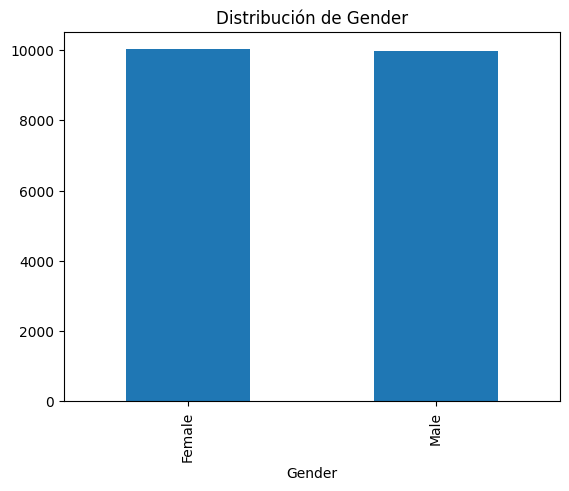

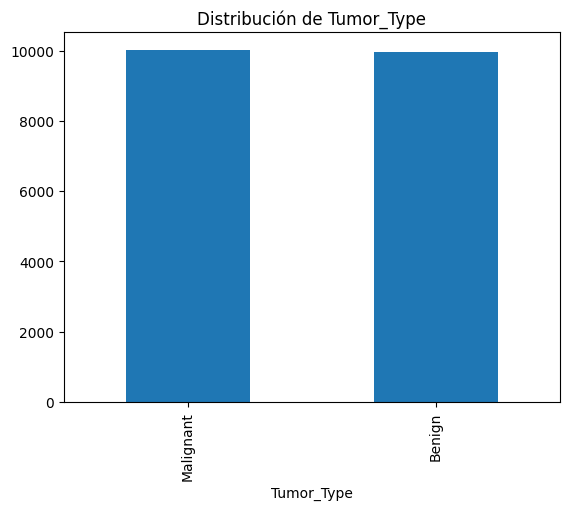

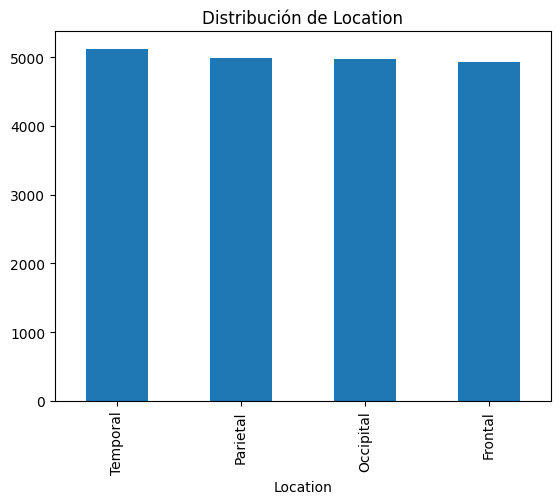

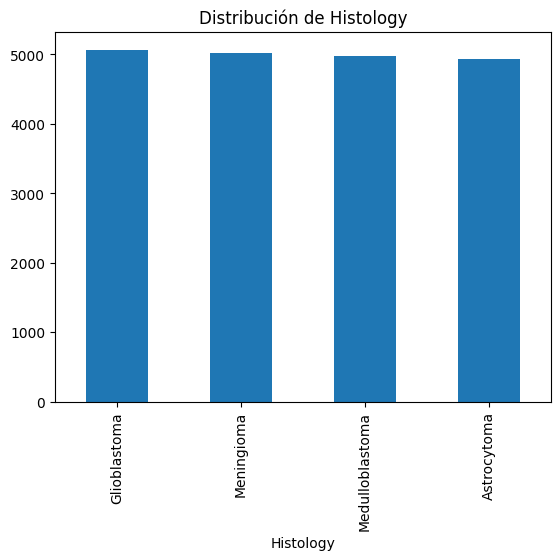

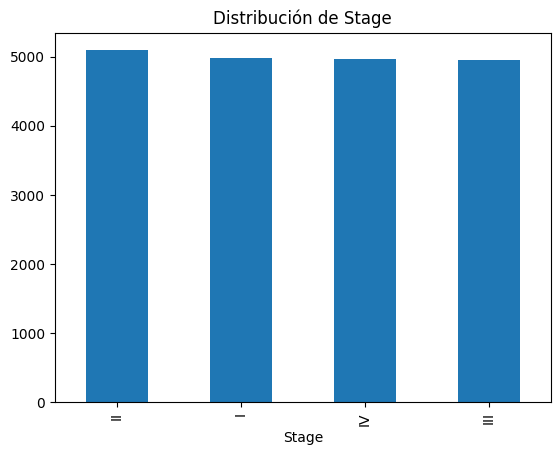

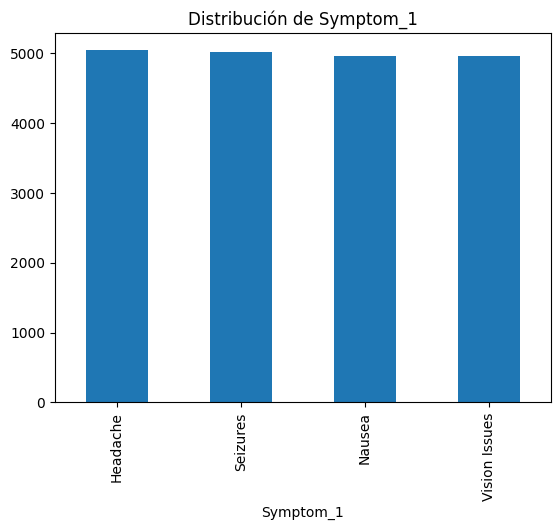

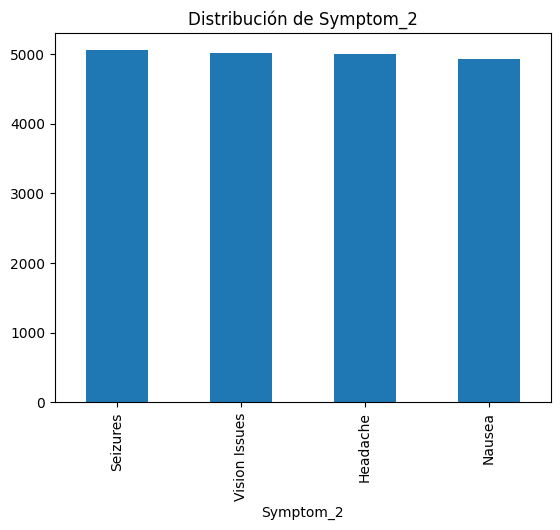

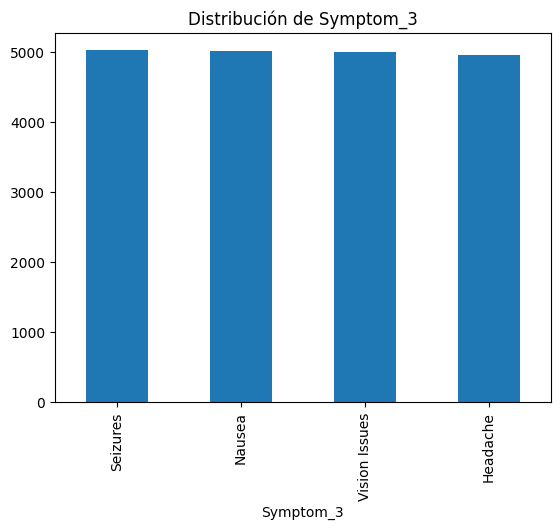

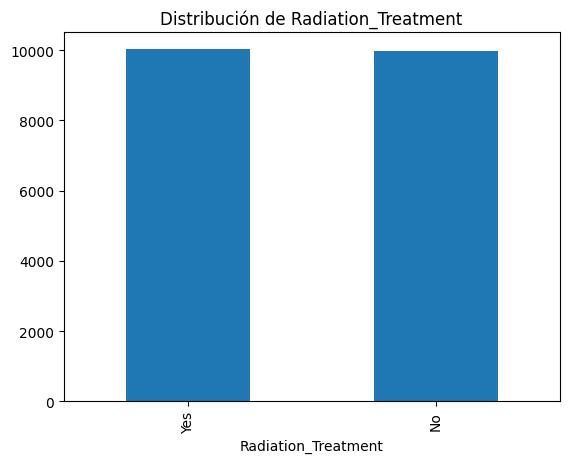

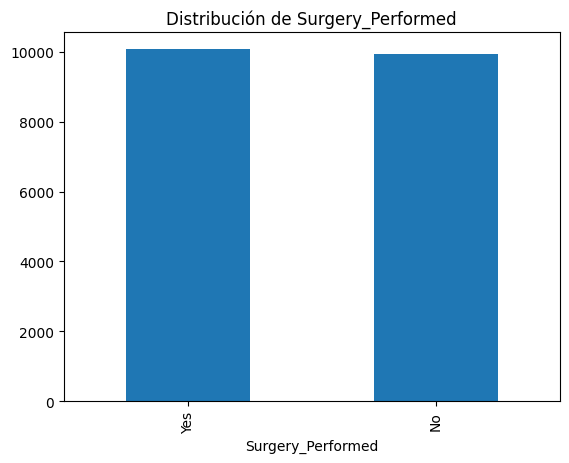

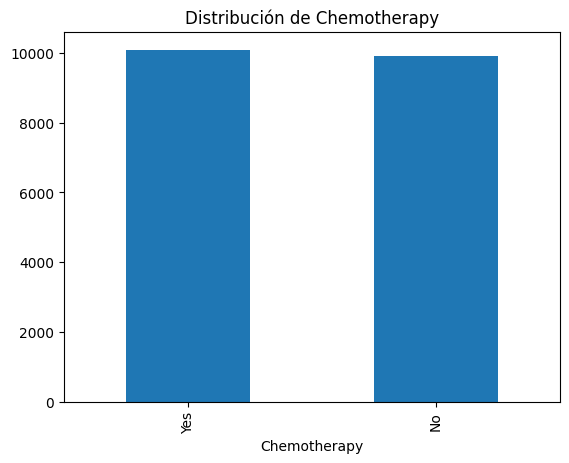

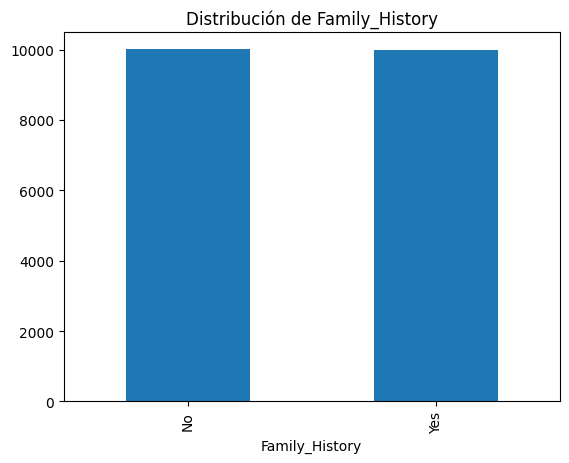

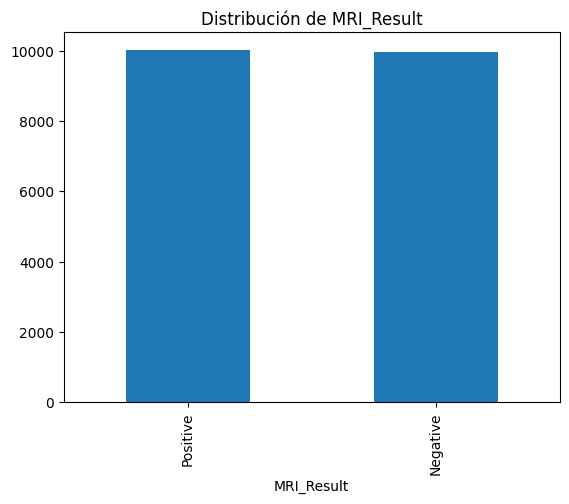

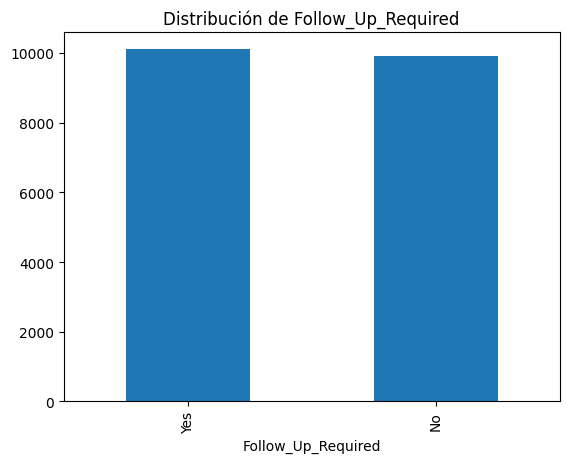

In [ ]:
for col in df.select_dtypes(include=['object', 'category']).columns:
    plt.figure()
    df[col].value_counts().plot(kind='bar')
    plt.title(f"Distribución de {col}")
    plt.show()

#### Para numéricas :

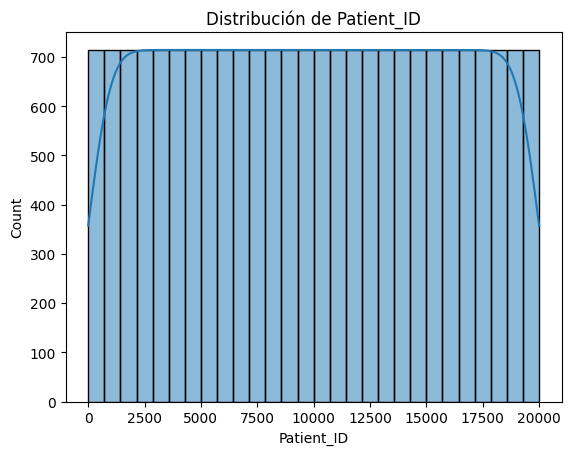

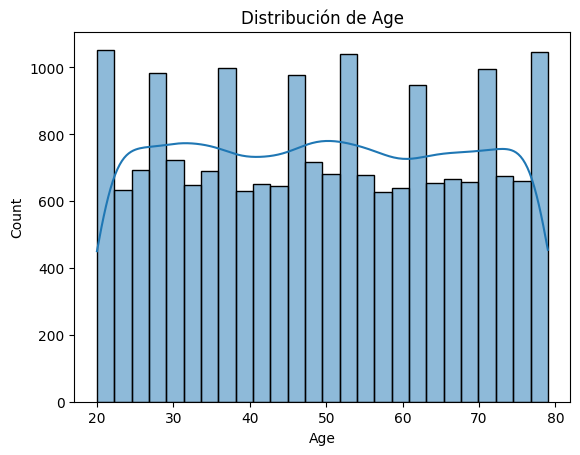

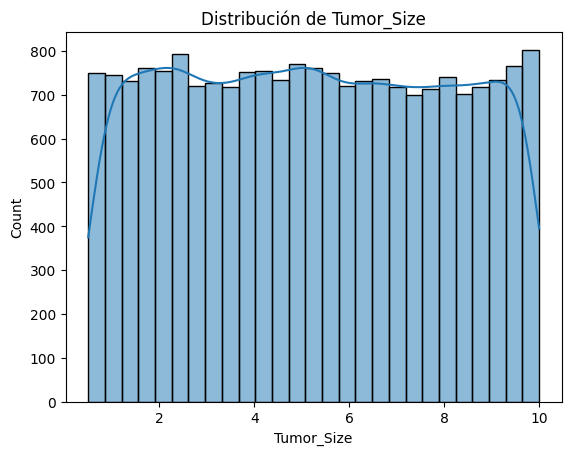

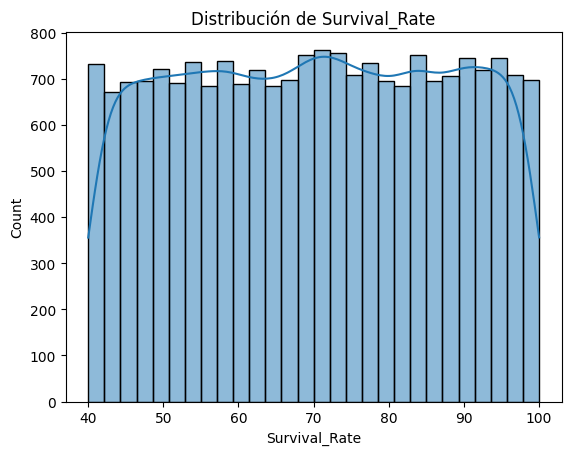

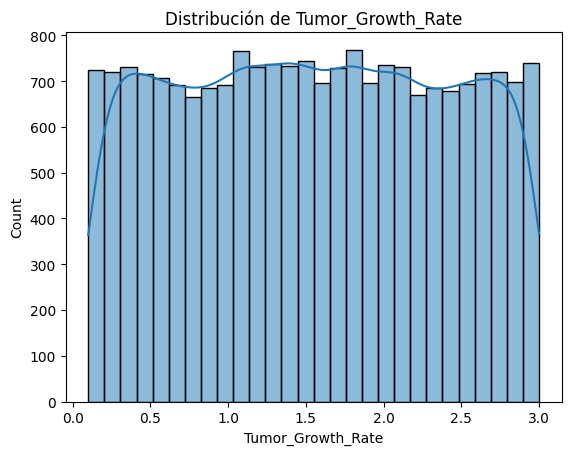

In [ ]:
for col in df.select_dtypes(include=['int64', 'float64']).columns:
    plt.figure()
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribución de {col}")
    plt.show()

In [ ]:
for col in df.columns:
    print(f"Columna: {col}")
    print(df[col].unique())
    print("-" * 40)

Columna: Patient_ID
[    1     2     3 ... 19998 19999 20000]
----------------------------------------
Columna: Age
[73 26 31 29 54 27 72 61 50 79 58 71 62 37 20 67 65 36 46 55 76 49 41 38
 63 44 56 70 42 64 48 52 78 23 39 33 32 34 30 25 75 43 47 28 60 66 35 57
 22 21 59 69 45 40 51 74 24 53 68 77]
----------------------------------------
Columna: Gender
['Male' 'Female']
----------------------------------------
Columna: Tumor_Type
['Malignant' 'Benign']
----------------------------------------
Columna: Tumor_Size
[5.37561155 4.84709779 5.58839071 ... 3.61863429 8.5190863  9.71676844]
----------------------------------------
Columna: Location
['Temporal' 'Parietal' 'Frontal' 'Occipital']
----------------------------------------
Columna: Histology
['Astrocytoma' 'Glioblastoma' 'Meningioma' 'Medulloblastoma']
----------------------------------------
Columna: Stage
['III' 'II' 'I' 'IV']
----------------------------------------
Columna: Symptom_1
['Vision Issues' 'Headache' 'Seizures' 'Nau

#### Filtramos los que tienes los 3 tratamientos :

In [ ]:
df_filtrado = df[
    (df['Radiation_Treatment'] == 'Yes') &
    (df['Surgery_Performed'] == 'Yes') &
    (df['Chemotherapy'] == 'Yes')
]

df_filtrado.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2590 entries, 1 to 19998
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Patient_ID           2590 non-null   int64  
 1   Age                  2590 non-null   int64  
 2   Gender               2590 non-null   object 
 3   Tumor_Type           2590 non-null   object 
 4   Tumor_Size           2590 non-null   float64
 5   Location             2590 non-null   object 
 6   Histology            2590 non-null   object 
 7   Stage                2590 non-null   object 
 8   Symptom_1            2590 non-null   object 
 9   Symptom_2            2590 non-null   object 
 10  Symptom_3            2590 non-null   object 
 11  Radiation_Treatment  2590 non-null   object 
 12  Surgery_Performed    2590 non-null   object 
 13  Chemotherapy         2590 non-null   object 
 14  Survival_Rate        2590 non-null   float64
 15  Tumor_Growth_Rate    2590 non-null   float

* En este caso vemos que los datos que nos quedaron fueron 2590 después de filtrar

## Ing de característics :

* Sacar X, Y y categorizar Y para que Malign sea =1 y Benign = 0
* Coficar categóricas (One hot)
* Codificar booleanos (One hot)
* Escalar (?) -> Standard Scaler
* Transformar cat ordinales a int, osea 'Stage'


In [7]:
df_work = df.drop('Patient_ID', axis=1)

Y = df_work['Tumor_Type'].map({'Malignant': 1, 'Benign': 0})
X = df_work.drop('Tumor_Type', axis=1)

# Booleanas
for col in ['Radiation_Treatment', 'Surgery_Performed', 'Chemotherapy', 'Family_History', 'Follow_Up_Required']:
    X[col] = X[col].map({'Yes': 1, 'No': 0})
X['MRI_Result'] = X['MRI_Result'].map({'Positive': 1, 'Negative': 0})

# Stage ordinal
X['Stage'] = X['Stage'].map({'I': 1, 'II': 2, 'III': 3, 'IV': 4})

# One-hot
X = pd.get_dummies(X, columns=['Gender', 'Location', 'Histology', 'Symptom_1', 'Symptom_2', 'Symptom_3'], drop_first=True)
print(f"X: {X.shape}, Y: {Y.shape}")

X: (20000, 27), Y: (20000,)


In [8]:
X.head()

,Age,Tumor_Size,Stage,Radiation_Treatment,Surgery_Performed,Chemotherapy,Survival_Rate,Tumor_Growth_Rate,Family_History,MRI_Result,...,Histology_Meningioma,Symptom_1_Nausea,Symptom_1_Seizures,Symptom_1_Vision Issues,Symptom_2_Nausea,Symptom_2_Seizures,Symptom_2_Vision Issues,Symptom_3_Nausea,Symptom_3_Seizures,Symptom_3_Vision Issues
0,73,5.375612,3,0,0,0,51.312579,0.111876,0,1,...,False,False,False,True,False,True,False,False,True,False
1,26,4.847098,2,1,1,1,46.373273,2.165736,1,1,...,False,False,False,False,False,False,False,True,False,False
2,31,5.588391,1,0,0,0,47.072221,1.884228,0,0,...,True,False,False,True,False,False,False,False,True,False
3,29,1.436600,4,1,0,1,51.853634,1.283342,1,0,...,False,False,False,True,False,True,False,False,False,False
4,54,2.417506,1,0,0,1,54.708987,2.069477,0,1,...,False,False,False,False,False,False,False,False,True,False


In [27]:
model = SVC(kernel='linear', random_state=42)

In [28]:
from sklearn.model_selection import cross_val_score, train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', model)
])

pipe.fit(X_train, y_train)
y_pred = pipe.predict(X_test)

print(f"F1 Score: {f1_score(y_test, y_pred):.4f}")
print("\nReporte:")
print(classification_report(y_test, y_pred))

F1 Score: 0.5176

Reporte:
              precision    recall  f1-score   support

           0       0.51      0.49      0.50      1997
           1       0.51      0.53      0.52      2003

    accuracy                           0.51      4000
   macro avg       0.51      0.51      0.51      4000
weighted avg       0.51      0.51      0.51      4000



In [17]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.metrics import f1_score, classification_report
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF

## Optimizacion Bayesiana - SVC kernel lineal con menos datos y k=5

In [29]:
## solo con 5000 datos :
np.random.seed(42)
idx_sample = np.random.choice(len(X), 5000, replace=False)
X_sample = X.iloc[idx_sample]
Y_sample = Y.iloc[idx_sample]
X.shape, Y.shape

((20000, 27), (20000,))

In [21]:
!pip install scikit-optimize

In [34]:
## LO HACEMOS CON BAYESSEARCHCV :
from skopt import BayesSearchCV
from skopt.space import Real

search_space = {'classifier__C': Real(1e-3, 1e3, prior='log-uniform')}

bayes_search = BayesSearchCV(pipe, search_space, n_iter=3,
    scoring='f1',
    cv=3,
    n_jobs=-1,
    random_state=42,
    verbose=3 )

In [ ]:
bayes_search.fit(X_sample, Y_sample)

Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits


## no terminó de cargar...

In [ ]:
bayes_search.best_params_

In [ ]:
bayes_search.best_score_